# Initial Test

In [1]:
%pwd

'/mnt/d/OneDrive/MLD01_Article/Code'

In [2]:
%cd ..

/mnt/d/OneDrive/MLD01_Article


/home/linux/anaconda3/envs/tf/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 351)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 275)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Rural_Dummy', 'Respon_Female', 'Respon_Age', 'LivingYear',
       'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor', 'Edu_Master',
       'Edu_PhD',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=273)

In [13]:
df_all["EcoBelt"] = df_all["EcoBelt"].astype("category")
df_all["EcoBelt"] = df_all["EcoBelt"].cat.codes

## Test

### Fit Model

In [15]:
y = df_all['HeardClimate_Dummy']
X = df_all.drop(columns = ['HeardClimate_Dummy'])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

In [20]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [21]:
clf = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",          # fast and memory-efficient
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

In [23]:
clf.fit(
    X_train, y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [24]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
try:
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
except ValueError:
    # If y is not binary or only one class present in y_test
    pass

Accuracy: 0.9723422644770959
ROC-AUC: 0.9949214634026807


In [26]:
print("\nClassification report:\n", classification_report(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       669
           1       0.98      0.95      0.97       488

    accuracy                           0.97      1157
   macro avg       0.97      0.97      0.97      1157
weighted avg       0.97      0.97      0.97      1157



### Importance

In [27]:
# Get importance values
importances = pd.Series(clf.feature_importances_, index=X_train.columns)

# Sort descending
importances = importances.sort_values(ascending=False)

print(importances.head(20))   # Top 20 important features

ClimateInfo_Radio             0.160563
ClimateInfo_Telev             0.135283
ClimateInfo_Neigh             0.093234
CookFuelS1                    0.063647
ClimateInfo_Aware             0.034910
ClimateInfo_News              0.034492
Edu_Illiterate                0.026333
ClimateInfo_Famil             0.021307
ClimateInfo_Local             0.018390
Edu12_Ratio                   0.017221
Edu_Master                    0.015821
ClimateInfo_Other             0.009325
PC_dummy                      0.009169
Net_dummy                     0.008524
ClimateChanged_Dummy          0.007549
BusiIncome                    0.007449
Edu_Literal                   0.006962
Respon_Female                 0.006673
CommunityPartipationPast25    0.006027
SkillTrainingPast25           0.005515
dtype: float32


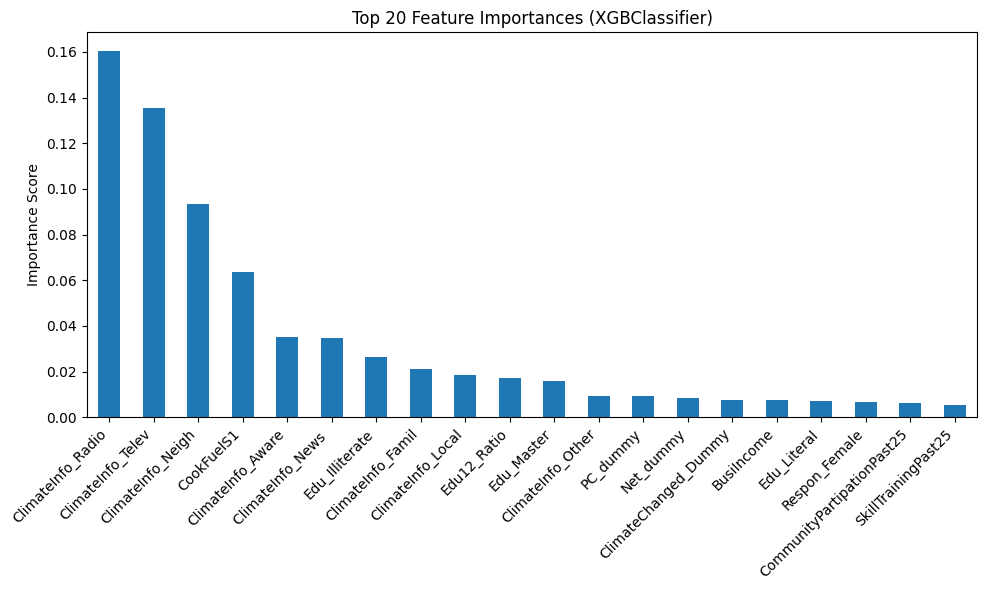

In [28]:
plt.figure(figsize=(10,6))
importances.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importances (XGBClassifier)")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()